In [1]:
import os, glob, random, zipfile, copy
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

ZIP_PATH = "/content/casting_product_image_data.zip"
EXTRACT_DIR = "/content/data"            # clean target folder

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

# Locate the folder that directly contains def_front and ok_front
data_dir = None
for root, dirs, _ in os.walk(EXTRACT_DIR):
    if "def_front" in dirs and "ok_front" in dirs:
        data_dir = root
        break

if data_dir is None:
    raise FileNotFoundError("def_front / ok_front not found. Run: !find /content/data -maxdepth 4 -type d")

print("data_dir:", data_dir)
for c in ["ok_front", "def_front"]:
    print(c, len(os.listdir(os.path.join(data_dir, c))), "images")

# Check image size (300x300 = original, 512x512 = augmented copy)
sample = glob.glob(os.path.join(data_dir, "def_front", "*.*"))[0]
print("Sample image size:", Image.open(sample).size)

Device: cuda
data_dir: /content/data/casting_data
ok_front 3000 images
def_front 3000 images
Sample image size: (300, 300)


**EDA Section**

In [2]:
import os, hashlib, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_DIR = Path("/content/data/casting_data")
CLASSES = {"ok_front": 0, "def_front": 1}   # 0 = normal, 1 = defective
EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

rows = []
for cls_name, label in CLASSES.items():
    for p in sorted((DATA_DIR / cls_name).iterdir()):
        if p.suffix.lower() in EXTS:
            rows.append({"path": str(p), "class_name": cls_name, "label": label})

df = pd.DataFrame(rows)
print(df.groupby("class_name").size())
print("Total:", len(df))

# Integrity + basic properties
props, bad = [], []
for p in tqdm(df["path"]):
    try:
        with Image.open(p) as im:
            im.verify()                      # detects corrupt files
        with Image.open(p) as im:
            props.append({"path": p, "width": im.width, "height": im.height,
                          "mode": im.mode, "format": im.format,
                          "size_kb": os.path.getsize(p) / 1024})
    except Exception as e:
        bad.append((p, str(e)))

print("Corrupt files:", len(bad))
df = df.merge(pd.DataFrame(props), on="path")
print(df[["width", "height", "mode", "format"]].astype(str).apply(Counter).to_dict())
print(df.groupby("class_name")[["size_kb"]].describe())

class_name
def_front    3000
ok_front     3000
dtype: int64
Total: 6000


100%|██████████| 6000/6000 [00:00<00:00, 6305.75it/s]

Corrupt files: 0
{'width': Counter({'300': 6000}), 'height': Counter({'300': 6000}), 'mode': Counter({'RGB': 6000}), 'format': Counter({'JPEG': 6000})}
           size_kb                                                    \
             count      mean       std       min       25%       50%   
class_name                                                             
def_front   3000.0  9.696473  0.558851  8.176758  9.313232  9.690430   
ok_front    3000.0  9.468701  0.623929  7.928711  8.889648  9.584961   

                                  
                  75%        max  
class_name                        
def_front   10.057617  11.872070  
ok_front     9.985596  11.302734  


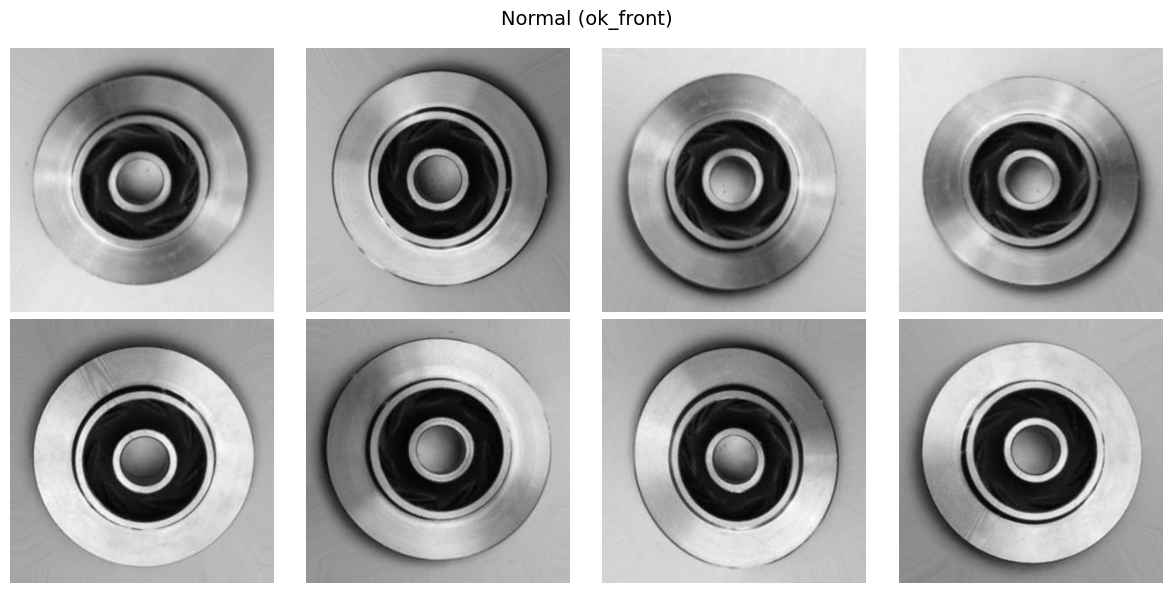

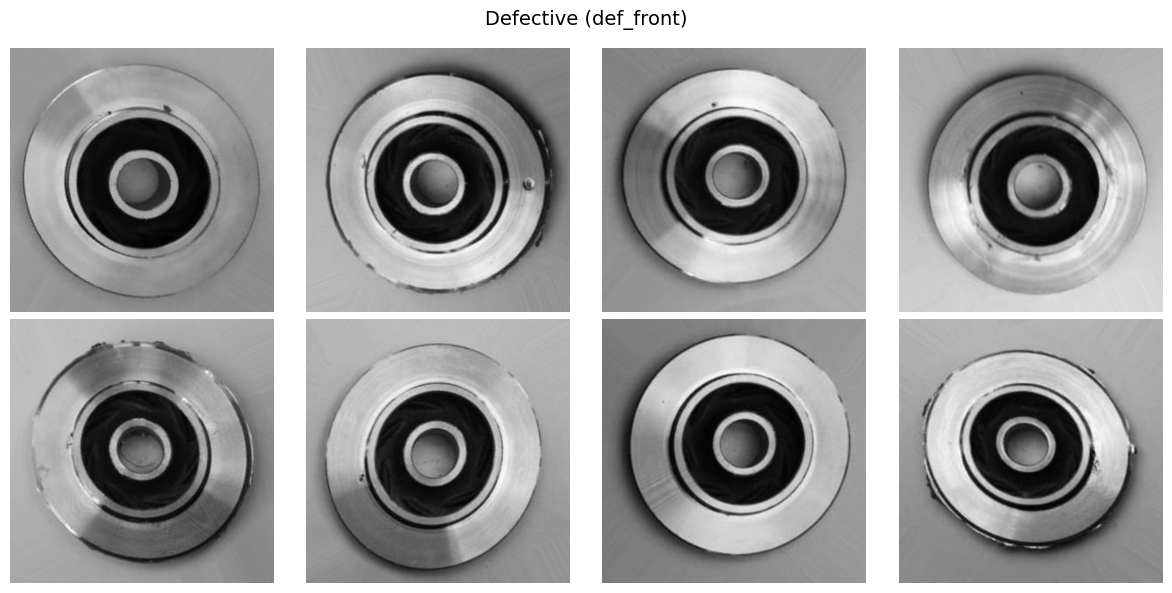

In [3]:
def show_grid(paths, title, n=8, cols=4):
    paths = random.sample(list(paths), n)
    rows_ = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows_, cols, figsize=(3*cols, 3*rows_))
    for ax, p in zip(axes.ravel(), paths):
        ax.imshow(Image.open(p), cmap="gray"); ax.axis("off")
    fig.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

show_grid(df[df.label == 0]["path"], "Normal (ok_front)")
show_grid(df[df.label == 1]["path"], "Defective (def_front)")


Grayscale-in-RGB fraction: 1.0


100%|██████████| 6000/6000 [00:09<00:00, 638.70it/s] 


(6000, 300, 300) uint8
           mean_px       std_px       sharp       size_kb      
              mean   std   mean   std  mean   std    mean   std
class_name                                                     
def_front   139.27  5.90  58.62  3.09  3.98  0.54    9.70  0.56
ok_front    149.82  6.47  62.28  2.73  3.79  0.49    9.47  0.62
Global mean/std (0-1): 0.5668492501815541 0.2395708059982055


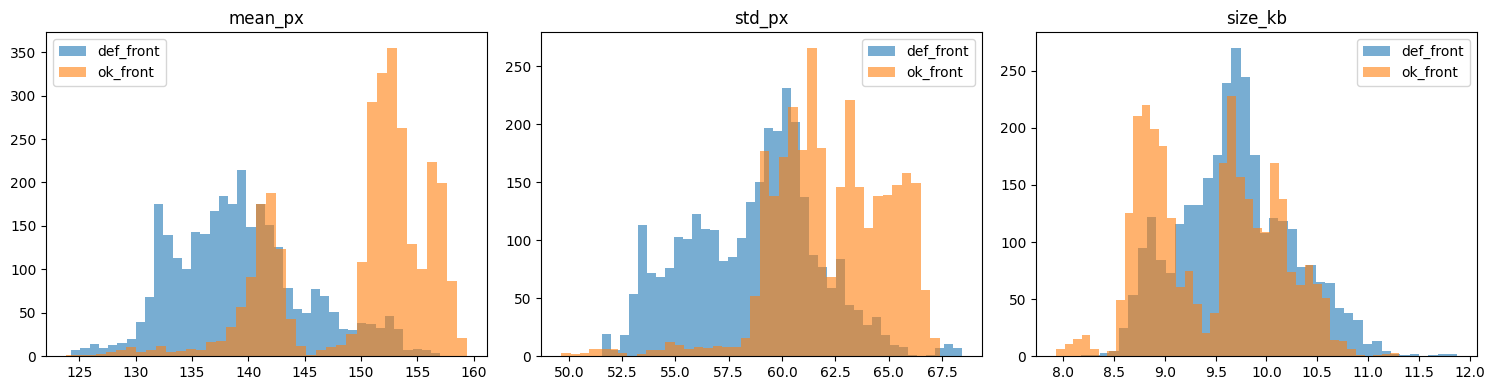

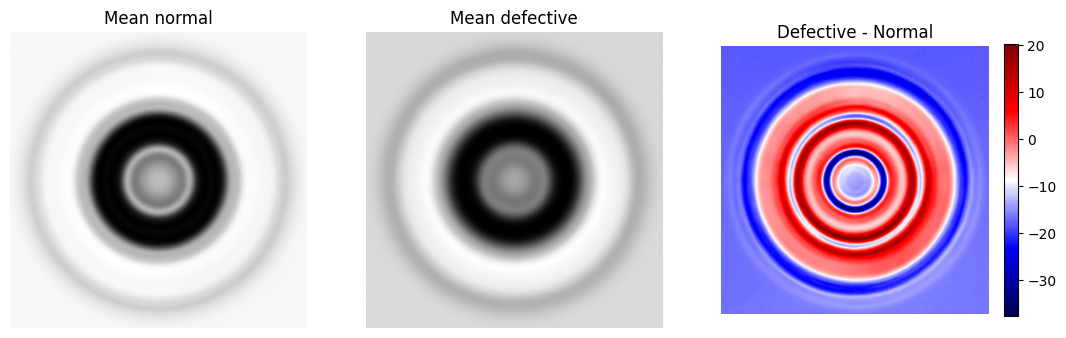

AUC using only size_kb: 0.596
AUC using only mean_px: 0.123
AUC using only std_px: 0.181
AUC using only sharp: 0.593


In [4]:
from sklearn.metrics import roc_auc_score

# 1) Are the 3 channels identical (i.e. true grayscale)?
sample = df.sample(300, random_state=SEED)
identical = []
for p in sample["path"]:
    a = np.asarray(Image.open(p)).astype(np.int16)
    identical.append(np.abs(a[..., 0] - a[..., 1]).max() <= 2 and np.abs(a[..., 0] - a[..., 2]).max() <= 2)
print("Grayscale-in-RGB fraction:", np.mean(identical))

# 2) Load everything as grayscale float arrays (6000x300x300 floats = ~2GB as float32, so use uint8)
imgs = np.stack([np.asarray(Image.open(p).convert("L")) for p in tqdm(df["path"])])  # uint8
labels = df["label"].values
print(imgs.shape, imgs.dtype)

# 3) Per-image brightness / contrast / sharpness and per-class summary
df["mean_px"] = imgs.reshape(len(imgs), -1).mean(1)
df["std_px"]  = imgs.reshape(len(imgs), -1).std(1)
lap = np.abs(np.diff(imgs.astype(np.float32), axis=1)).mean((1, 2))   # cheap sharpness proxy
df["sharp"] = lap
print(df.groupby("class_name")[["mean_px", "std_px", "sharp", "size_kb"]].agg(["mean", "std"]).round(2))

# 4) Dataset-level normalization stats (use TRAIN only later; this is for exploration)
print("Global mean/std (0-1):", imgs.mean() / 255, imgs.std() / 255)

# 5) Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["mean_px", "std_px", "size_kb"]):
    for name, g in df.groupby("class_name"):
        ax.hist(g[col], bins=40, alpha=0.6, label=name)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

# 6) Mean image per class and their difference
m_ok  = imgs[labels == 0].mean(0)
m_def = imgs[labels == 1].mean(0)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(m_ok, cmap="gray");  axes[0].set_title("Mean normal")
axes[1].imshow(m_def, cmap="gray"); axes[1].set_title("Mean defective")
im = axes[2].imshow(m_def - m_ok, cmap="seismic"); axes[2].set_title("Defective - Normal")
for a in axes: a.axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046); plt.show()

# 7) Shortcut check: how well do trivial features predict the label? (0.5 = no signal)
for col in ["size_kb", "mean_px", "std_px", "sharp"]:
    print(f"AUC using only {col}: {roc_auc_score(df['label'], df[col]):.3f}")

Exact-duplicate images: 0
Exact duplicates spanning both classes: 0


100%|██████████| 6000/6000 [00:03<00:00, 1981.09it/s]


Hamming <= 0: 423 pairs (8 cross-class)
Hamming <= 2: 4233 pairs (144 cross-class)
Hamming <= 4: 19271 pairs (1954 cross-class)
Hamming <= 6: 78977 pairs (16862 cross-class)
Hamming <= 8: 265994 pairs (80076 cross-class)


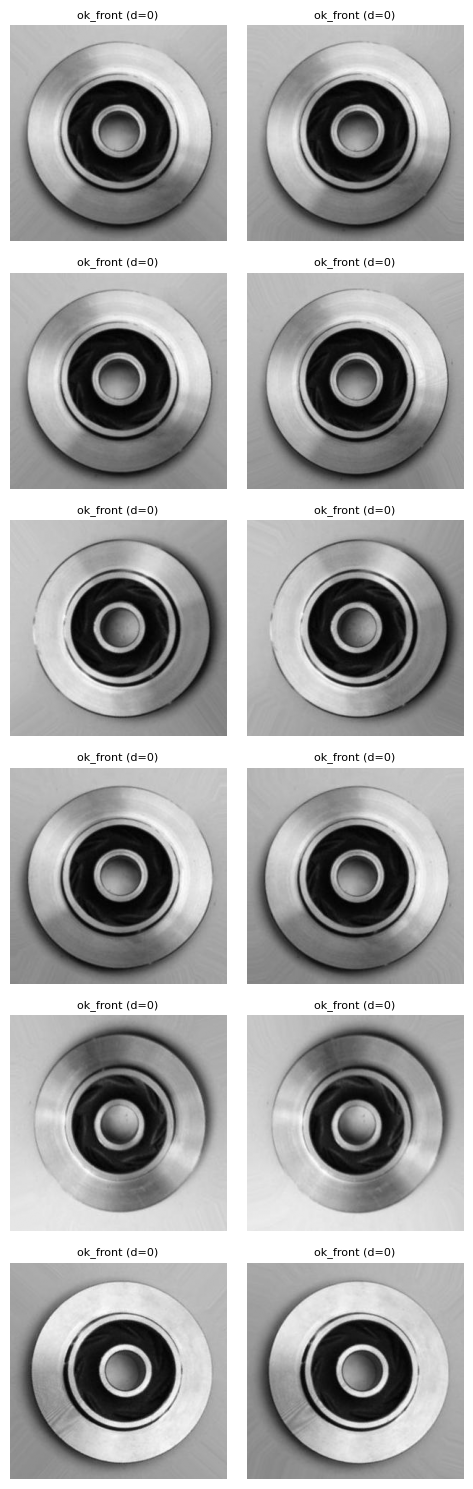

In [5]:
# 1) Exact duplicates
df["md5"] = [hashlib.md5(open(p, "rb").read()).hexdigest() for p in df["path"]]
dup = df[df.duplicated("md5", keep=False)]
print("Exact-duplicate images:", len(dup))
print("Exact duplicates spanning both classes:", (dup.groupby("md5")["label"].nunique() > 1).sum())

# 2) Perceptual hash (dHash, 8x8 = 64 bits), no extra libraries needed
def dhash(arr, size=8):
    im = Image.fromarray(arr).resize((size + 1, size), Image.LANCZOS)
    a = np.asarray(im, dtype=np.int16)
    return (a[:, 1:] > a[:, :-1]).flatten()

H = np.stack([dhash(a) for a in tqdm(imgs)]).astype(np.float32)      # (N, 64)
ham = 64 - (H @ H.T + (1 - H) @ (1 - H).T)                           # pairwise Hamming distance
np.fill_diagonal(ham, 99)

for thr in [0, 2, 4, 6, 8]:
    i, j = np.where(np.triu(ham <= thr))
    cross = (labels[i] != labels[j]).sum()
    print(f"Hamming <= {thr}: {len(i)} pairs ({cross} cross-class)")

# 3) Look at the closest pairs
i, j = np.where(np.triu(ham <= 4))
order = np.argsort(ham[i, j])[:6]
fig, axes = plt.subplots(len(order), 2, figsize=(5, 2.5 * len(order)))
for k, o in enumerate(order):
    for c, idx in enumerate([i[o], j[o]]):
        axes[k, c].imshow(imgs[idx], cmap="gray"); axes[k, c].axis("off")
        axes[k, c].set_title(f"{df.class_name[idx]} (d={int(ham[i[o], j[o]])})", fontsize=8)
plt.tight_layout(); plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

# 1) Is the darkness a uniform shift (lighting) or localized (defects)?
diff = m_def - m_ok
print("Mean-diff: mean=%.2f, std=%.2f, min=%.2f, max=%.2f" % (diff.mean(), diff.std(), diff.min(), diff.max()))

# Typical normal part: use the median pixel instead of the mean (robust to small dark defects)
df["median_px"] = np.median(imgs.reshape(len(imgs), -1), axis=1)
print("AUC using median_px:", round(roc_auc_score(df["label"], -df["median_px"]), 3))
print(df.groupby("class_name")["median_px"].agg(["mean", "std"]).round(2))

# 2) Border-only brightness (where defects are less likely) vs center brightness
border = np.concatenate([imgs[:, :20, :].reshape(len(imgs), -1), imgs[:, -20:, :].reshape(len(imgs), -1)], axis=1).mean(1)
center = imgs[:, 100:200, 100:200].reshape(len(imgs), -1).mean(1)
print("AUC border brightness:", round(roc_auc_score(df["label"], -border), 3))
print("AUC center brightness:", round(roc_auc_score(df["label"], -center), 3))

# 3) After per-image standardization, does any global signal remain?
norm = (imgs.astype(np.float32) - imgs.mean((1, 2), keepdims=True)) / imgs.std((1, 2), keepdims=True)
df["skew"] = ((norm ** 3).mean((1, 2)))
df["p01"]  = np.percentile(norm.reshape(len(norm), -1), 1, axis=1)   # dark tail (holes/dots)
print("AUC skew after norm:", round(roc_auc_score(df["label"], df["skew"]), 3))
print("AUC dark-tail p01:", round(roc_auc_score(df["label"], -df["p01"]), 3))

# 4) Shortcut baseline: logistic regression on global features only (5-fold CV)
feats = df[["mean_px", "std_px", "sharp", "size_kb"]].values
feats = (feats - feats.mean(0)) / feats.std(0)
proba = cross_val_predict(LogisticRegression(), feats, df["label"], cv=5, method="predict_proba")[:, 1]
print("Shortcut baseline AUC (CV):", round(roc_auc_score(df["label"], proba), 3))
print("Shortcut baseline accuracy:", round(((proba > 0.5) == df["label"]).mean(), 3))

Mean-diff: mean=-10.55, std=9.99, min=-37.76, max=20.22
AUC using median_px: 0.863
              mean   std
class_name              
def_front   153.91  8.82
ok_front    166.52  6.88
AUC border brightness: 0.813
AUC center brightness: 0.83
AUC skew after norm: 0.573
AUC dark-tail p01: 0.435
Shortcut baseline AUC (CV): 0.904
Shortcut baseline accuracy: 0.838


train test split

In [7]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import StratifiedGroupKFold

# Group near-duplicates (needs `ham` from chunk 4). Pick the loosest threshold
# that doesn't create giant groups (casting images look alike, so hashes can over-link).
for thr in [6, 4, 2, 1, 0]:
    n_groups, group_id = connected_components(csr_matrix(ham <= thr), directed=False)
    biggest = np.bincount(group_id).max()
    print(f"thr={thr}: {n_groups} groups, largest={biggest}")
    if biggest <= 30:
        break
df["group"] = group_id
print("Chosen thr:", thr)
print("Groups with mixed labels (possible label errors):", (df.groupby("group")["label"].nunique() > 1).sum())

# ~71/14/14 stratified, group-aware split
sg1 = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
trval_idx, test_idx = next(sg1.split(df, df.label, df.group))
sub = df.iloc[trval_idx]
sg2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
tr_i, va_i = next(sg2.split(sub, sub.label, sub.group))

df["split"] = ""
df.loc[sub.index[tr_i], "split"] = "train"
df.loc[sub.index[va_i], "split"] = "val"
df.loc[df.index[test_idx], "split"] = "test"

print(df.groupby(["split", "class_name"]).size().unstack())
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    assert not set(df[df.split == a].group) & set(df[df.split == b].group), f"group leak {a}/{b}"
print("No group leakage across splits")
df[["path", "label", "class_name", "group", "split"]].to_csv("split.csv", index=False)

thr=6: 266 groups, largest=5669
thr=4: 1266 groups, largest=4072
thr=2: 3618 groups, largest=104
thr=1: 4873 groups, largest=18
Chosen thr: 1
Groups with mixed labels (possible label errors): 17
class_name  def_front  ok_front
split                          
test              435       429
train            2127      2141
val               438       430
No group leakage across splits


**preprocessing**

In [15]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T

device = "cuda" if torch.cuda.is_available() else "cpu"
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()

X = torch.from_numpy(imgs)                         # (N,300,300) uint8, from chunk 3
Y = torch.from_numpy(df.label.values).float()
idx = {s: np.where(df.split.values == s)[0] for s in ["train", "val", "test"]}

tr_pix = imgs[idx["train"]]
TRAIN_MEAN, TRAIN_STD = float(tr_pix.mean() / 255), float(tr_pix.std() / 255)   # train-only stats
print("Train mean/std:", TRAIN_MEAN, TRAIN_STD)

class Rot90:
    def __call__(self, x): return torch.rot90(x, random.randint(0, 3), dims=(-2, -1))

def build_aug(rot=10, trans=0.03):
    # Geometric only: no cutout/crop (could erase small defects). Brightness jitter is
    # unnecessary because per-image standardization removes global brightness/contrast.
    return T.Compose([T.RandomHorizontalFlip(), T.RandomVerticalFlip(), Rot90(),
                      T.RandomAffine(degrees=rot, translate=(trans, trans))])

def standardize(x, mode):
    if mode == "per_image":
        return (x - x.mean()) / (x.std() + 1e-6)
    return (x - TRAIN_MEAN) / TRAIN_STD            # "global"

class CastingDS(Dataset):
    def __init__(self, ids, aug=None, norm="per_image"):
        self.ids, self.aug, self.norm = ids, aug, norm
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        j = self.ids[i]
        x = X[j].unsqueeze(0).float() / 255.0
        if self.aug: x = self.aug(x)
        return standardize(x, self.norm), Y[j]

def make_loaders(bs=64, rot=10, trans=0.03, norm="per_image", workers=2):
    mk = lambda s, aug, sh: DataLoader(CastingDS(idx[s], aug, norm), batch_size=bs, shuffle=sh,
                                       num_workers=workers, pin_memory=True, drop_last=sh)
    return (mk("train", build_aug(rot, trans), True), mk("val", None, False), mk("test", None, False))

tl, vl, _ = make_loaders()
xb, yb = next(iter(tl)); print(xb.shape, xb.mean().item(), xb.std().item(), yb.mean().item())

Train mean/std: 0.567068271506249 0.23966265148196167
torch.Size([64, 1, 300, 300]) -7.894303877264974e-09 0.999990701675415 0.515625


In [16]:
import math
import torch.nn.functional as F
torch.backends.cudnn.benchmark = True

X_gpu = X.to(device)                      # (N,300,300) uint8, stays on GPU
Y_gpu = Y.to(device)

class GPULoader:
    """In-GPU batching + augmentation (flips, rot90, small rotation/translation) + standardization."""
    def __init__(self, split, bs, train, rot=10, trans=0.03, norm="per_image", frac=1.0):
        ids = idx[split]
        if frac < 1.0:
            ids = np.random.RandomState(SEED).choice(ids, int(len(ids) * frac), replace=False)
        self.ids = torch.as_tensor(ids, device=device)
        self.dataset = self.ids                           # so len(loader.dataset) works
        self.bs, self.train, self.rot, self.trans, self.norm = bs, train, rot, trans, norm

    def __len__(self):
        n = len(self.ids)
        return n // self.bs if self.train else math.ceil(n / self.bs)

    def _augment(self, x):
        B = x.size(0)
        m = torch.rand(B, device=device) < 0.5; x = torch.where(m[:, None, None, None], x.flip(3), x)
        m = torch.rand(B, device=device) < 0.5; x = torch.where(m[:, None, None, None], x.flip(2), x)
        k = torch.randint(0, 4, (B,), device=device); out = x.clone()
        for kk in (1, 2, 3):
            mk = k == kk
            if mk.any(): out[mk] = torch.rot90(x[mk], kk, dims=(2, 3))
        x = out
        if self.rot > 0 or self.trans > 0:
            ang = (torch.rand(B, device=device) * 2 - 1) * self.rot * math.pi / 180
            tx = (torch.rand(B, device=device) * 2 - 1) * self.trans * 2
            ty = (torch.rand(B, device=device) * 2 - 1) * self.trans * 2
            c, s = ang.cos(), ang.sin()
            theta = torch.stack([torch.stack([c, -s, tx], 1), torch.stack([s, c, ty], 1)], 1)
            grid = F.affine_grid(theta, list(x.shape), align_corners=False)
            x = F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
        return x

    def _norm(self, x):
        if self.norm == "per_image":
            m = x.mean((1, 2, 3), keepdim=True); s = x.std((1, 2, 3), keepdim=True)
            return (x - m) / (s + 1e-6)
        return (x - TRAIN_MEAN) / TRAIN_STD

    def __iter__(self):
        n = len(self.ids)
        perm = torch.randperm(n, device=device) if self.train else torch.arange(n, device=device)
        for b in range(len(self)):
            sel = self.ids[perm[b * self.bs:(b + 1) * self.bs]]
            x = X_gpu[sel].float().div_(255).unsqueeze(1)
            if self.train: x = self._augment(x)
            yield self._norm(x), Y_gpu[sel]

def make_loaders(bs=64, rot=10, trans=0.03, norm="per_image", train_frac=1.0, **_):
    return (GPULoader("train", bs, True, rot, trans, norm, train_frac),
            GPULoader("val", 256, False, norm=norm),
            GPULoader("test", 256, False, norm=norm))

# predict() must move labels off the GPU now, so redefine it:
@torch.no_grad()
def predict(model, loader):
    model.eval(); ps, ys = [], []
    for x, y in loader:
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=device == "cuda"):
            lo = model(x).squeeze(1)
        ps.append(torch.sigmoid(lo.float()).cpu()); ys.append(y.cpu())
    return torch.cat(ps).numpy(), torch.cat(ys).numpy()

# Speed + sanity check
tl, vl, te = make_loaders(64)
xb, yb = next(iter(tl)); print(xb.shape, round(xb.mean().item(), 3), round(xb.std().item(), 3), yb.mean().item())
t = time.perf_counter(); seed_everything()
m, h, ap = train_model(LightCNN(), tl, vl, epochs=2)
print(f"2 epochs took {time.perf_counter() - t:.1f}s")

torch.Size([64, 1, 300, 300]) -0.0 1.0 0.5
ep00 train 0.5914 | val loss 0.3524 AP 0.9361 F1 0.8286
ep01 train 0.3369 | val loss 0.3168 AP 0.9609 F1 0.8950
2 epochs took 13.0s


**Model Squential Block**

In [17]:
import torch, torch.nn as nn

def _c(v):
    """Round channel counts to a multiple of 8 (min 8) so width multipliers stay valid."""
    return max(8, int(round(v / 8) * 8))

class DSConv(nn.Module):
    """Depthwise-separable conv block: 3x3 depthwise -> 1x1 pointwise -> BN -> SiLU."""
    def __init__(self, cin, cout):
        super().__init__()
        self.dw = nn.Conv2d(cin, cin, 3, padding=1, groups=cin, bias=False)
        self.pw = nn.Conv2d(cin, cout, 1, bias=False)
        self.bn = nn.BatchNorm2d(cout)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

class LightCNN(nn.Module):
    """
    Lightweight CNN trained from scratch for 1-channel 300x300 casting images.
    Stem: 3x3 stride-2 conv. Stages: [DSConv, DSConv, (Dropout2d), MaxPool] x depth.
    Head: global max and/or avg pooling -> Dropout -> Linear -> 1 logit.
    """
    def __init__(self, width=1.0, depth=4, dropout=0.3, pool="maxavg", spatial_drop=0.0):
        super().__init__()
        assert pool in ("avg", "max", "maxavg") and 1 <= depth <= 5
        ch = [_c(c * width) for c in (16, 32, 64, 96, 128, 192)]

        layers = [nn.Conv2d(1, ch[0], 3, stride=2, padding=1, bias=False),
                  nn.BatchNorm2d(ch[0]), nn.SiLU(inplace=True)]
        for i in range(depth):
            layers += [DSConv(ch[i], ch[i + 1]), DSConv(ch[i + 1], ch[i + 1])]
            if spatial_drop > 0 and i >= depth - 2:
                layers.append(nn.Dropout2d(spatial_drop))
            layers.append(nn.MaxPool2d(2))

        self.features = nn.Sequential(*layers)
        self.pool = pool
        feat_dim = ch[depth] * (2 if pool == "maxavg" else 1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim, 1))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):
        f = self.features(x)
        mx, av = f.amax((2, 3)), f.mean((2, 3))
        z = {"max": mx, "avg": av, "maxavg": torch.cat([mx, av], 1)}[self.pool]
        return self.head(z)          # (B, 1) raw logit

def n_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6

# Sanity check: output shape and size for a few configs
for cfg in [dict(width=0.5, depth=3), dict(width=1.0, depth=4), dict(width=1.5, depth=5, spatial_drop=0.1)]:
    m = LightCNN(**cfg).to(device).eval()
    with torch.no_grad():
        out = m(torch.zeros(2, 1, 300, 300, device=device))
    print(cfg, "->", tuple(out.shape), f"{n_params(m):.3f}M params")

{'width': 0.5, 'depth': 3} -> (2, 1) 0.008M params
{'width': 1.0, 'depth': 4} -> (2, 1) 0.058M params
{'width': 1.5, 'depth': 5, 'spatial_drop': 0.1} -> (2, 1) 0.270M params


In [18]:
!pip -q install optuna
import copy, time, optuna
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             log_loss, precision_recall_curve)

@torch.no_grad()
def predict(model, loader):
    """Returns (probabilities, labels) as numpy arrays."""
    model.eval(); ps, ys = [], []
    for x, y in loader:
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=device == "cuda"):
            lo = model(x).squeeze(1)
        ps.append(torch.sigmoid(lo.float()).cpu()); ys.append(y.cpu())
    return torch.cat(ps).numpy(), torch.cat(ys).numpy()

def train_model(model, tl, vl, epochs=20, lr=1e-3, wd=1e-4, ls=0.0, pos_weight=1.0,
                patience=8, trial=None, verbose=True):
    """AdamW + OneCycle + AMP. Best epoch chosen by (val AP, -val loss). Supports Optuna pruning."""
    model = model.to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=device))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * len(tl))
    scaler = torch.amp.GradScaler(enabled=device == "cuda")
    best, best_state, bad, hist = (-1.0, 9e9), None, 0, []

    for ep in range(epochs):
        model.train(); tot = 0.0
        for x, y in tl:
            y = y * (1 - ls) + 0.5 * ls                      # label smoothing
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=device == "cuda"):
                loss = crit(model(x).squeeze(1), y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            tot += loss.item() * len(x)

        p, yv = predict(model, vl)
        ap = average_precision_score(yv, p)
        vloss = log_loss(yv, np.clip(p, 1e-6, 1 - 1e-6), labels=[0, 1])
        f1 = f1_score(yv, p > 0.5)
        hist.append(dict(epoch=ep, train_loss=tot / (len(tl) * tl.bs), val_loss=vloss, val_ap=ap, val_f1=f1))
        if verbose:
            print(f"ep{ep:02d} train {hist[-1]['train_loss']:.4f} | val loss {vloss:.4f} AP {ap:.4f} F1 {f1:.4f}")

        if (ap, -vloss) > (best[0], -best[1]):
            best, best_state, bad = (ap, vloss), copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience: break

        if trial is not None:
            trial.report(ap, ep)
            if trial.should_prune(): raise optuna.TrialPruned()

    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist), best[0]

# Smoke test + timing (3 epochs)
seed_everything()
tl, vl, _ = make_loaders(64)
xb, yb = next(iter(tl)); print(xb.shape, round(xb.mean().item(), 3), round(xb.std().item(), 3), yb.mean().item())
t = time.perf_counter()
m, h, ap = train_model(LightCNN(), tl, vl, epochs=3)
print(f"3 epochs took {time.perf_counter() - t:.1f}s")

torch.Size([64, 1, 300, 300]) -0.0 1.0 0.5
ep00 train 0.6436 | val loss 0.6587 AP 0.9175 F1 0.7155
ep01 train 0.3323 | val loss 0.2334 AP 0.9717 F1 0.9115
ep02 train 0.2145 | val loss 0.1864 AP 0.9833 F1 0.9347
3 epochs took 20.0s


**Optuna hyperparameter search**

In [20]:
SEARCH_EPOCHS = 10          # enough to rank configs; the final model trains longer in chunk 10

def objective(trial):
    seed_everything()
    c = dict(width=trial.suggest_categorical("width", [0.5, 0.75, 1.0, 1.5]),
             depth=trial.suggest_int("depth", 3, 5),
             dropout=trial.suggest_float("dropout", 0.0, 0.5),
             spatial_drop=trial.suggest_float("spatial_drop", 0.0, 0.15),
             pool=trial.suggest_categorical("pool", ["avg", "max", "maxavg"]),
             lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
             wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
             bs=trial.suggest_categorical("bs", [32, 64, 128]),
             rot=trial.suggest_int("rot", 0, 25, step=5),
             trans=trial.suggest_float("trans", 0.0, 0.08),
             ls=trial.suggest_float("ls", 0.0, 0.1))

    tl_, vl_, _ = make_loaders(c["bs"], c["rot"], c["trans"])
    model = LightCNN(c["width"], c["depth"], c["dropout"], c["pool"], c["spatial_drop"])
    trial.set_user_attr("params_M", round(n_params(model), 3))

    model, _, ap = train_model(model, tl_, vl_, epochs=SEARCH_EPOCHS, lr=c["lr"], wd=c["wd"],
                               ls=c["ls"], patience=4, trial=trial, verbose=False)
    del model; torch.cuda.empty_cache()
    return ap                                    # maximize validation average precision

study = optuna.create_study(
    direction="maximize", study_name="casting_lightcnn_v3",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=3),
    storage="sqlite:///optuna_casting.db", load_if_exists=True)

study.optimize(objective, n_trials=4, timeout=20 * 60, show_progress_bar=True)   # stops at 20 trials or 20 min

print("Best val AP:", study.best_value)
print(study.best_params)
tdf = study.trials_dataframe()
print(tdf[["number", "value", "params_width", "params_depth", "params_lr", "user_attrs_params_M", "state"]]
      .sort_values("value", ascending=False).head(8))
if len(study.get_trials(states=[optuna.trial.TrialState.COMPLETE])) > 5:
    print(optuna.importance.get_param_importances(study))

[I 2026-10-07 10:20:22,237] Using an existing study with `study_name='casting_lightcnn_v3'` instead of creating a new one.


  0%|          | 0/4 [00:00<?, ?it/s]

[I 2026-10-07 10:21:23,778] Trial 2 finished with value: 0.9834058511343038 and parameters: {'width': 0.75, 'depth': 3, 'dropout': 0.07799726016810132, 'spatial_drop': 0.008712541825229918, 'pool': 'avg', 'lr': 0.00010994335574766199, 'wd': 0.00757947995334801, 'bs': 32, 'rot': 5, 'trans': 0.02433937943676302, 'ls': 0.052475643163223784}. Best is trial 0 with value: 0.9834058511343038.
[I 2026-10-07 10:22:19,498] Trial 3 finished with value: 0.9994350316317875 and parameters: {'width': 1.0, 'depth': 3, 'dropout': 0.18318092164684585, 'spatial_drop': 0.06841049763255538, 'pool': 'avg', 'lr': 0.0015304852121831463, 'wd': 1.5339162591163623e-06, 'bs': 32, 'rot': 25, 'trans': 0.07725056264596475, 'ls': 0.08083973481164612}. Best is trial 3 with value: 0.9994350316317875.
[I 2026-10-07 10:23:31,116] Trial 4 finished with value: 0.993374061743061 and parameters: {'width': 1.0, 'depth': 3, 'dropout': 0.2475884550556351, 'spatial_drop': 0.005158278167282759, 'pool': 'avg', 'lr': 0.000420167205

/tmp/ipykernel_1333/1728514846.py:34: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()


[I 2026-10-07 10:23:58,759] Trial 5 pruned. 
Best val AP: 0.9994350316317875
{'width': 1.0, 'depth': 3, 'dropout': 0.18318092164684585, 'spatial_drop': 0.06841049763255538, 'pool': 'avg', 'lr': 0.0015304852121831463, 'wd': 1.5339162591163623e-06, 'bs': 32, 'rot': 25, 'trans': 0.07725056264596475, 'ls': 0.08083973481164612}
   number     value  params_width  params_depth  params_lr  \
3       3  0.999435          1.00             3   0.001530   
4       4  0.993374          1.00             3   0.000420   
0       0  0.983406          0.75             3   0.000110   
2       2  0.983406          0.75             3   0.000110   
5       5  0.918635          0.75             3   0.000365   
1       1       NaN          1.00             3   0.001530   

   user_attrs_params_M     state  
3                0.027  COMPLETE  
4                0.027  COMPLETE  
0                0.016  COMPLETE  
2                0.016  COMPLETE  
5                0.016    PRUNED  
1                0.027      FA

**final training, threshold selection, test evaluation, and error analysis**

ep00 train 0.6882 | val loss 0.6702 AP 0.7920 F1 0.7057
ep01 train 0.6651 | val loss 0.6135 AP 0.8932 F1 0.7184
ep02 train 0.5782 | val loss 0.4633 AP 0.9588 F1 0.8089
ep03 train 0.4379 | val loss 0.3073 AP 0.9806 F1 0.9103
ep04 train 0.3594 | val loss 0.3959 AP 0.9933 F1 0.8082
ep05 train 0.3089 | val loss 0.2421 AP 0.9965 F1 0.9305
ep06 train 0.2660 | val loss 0.2688 AP 0.9971 F1 0.8668
ep07 train 0.2551 | val loss 0.2457 AP 0.9939 F1 0.8857
ep08 train 0.2417 | val loss 0.1468 AP 0.9991 F1 0.9668
ep09 train 0.2383 | val loss 0.3811 AP 0.9965 F1 0.7942
ep10 train 0.2338 | val loss 0.1494 AP 0.9974 F1 0.9897
ep11 train 0.2272 | val loss 0.1216 AP 0.9985 F1 0.9645
ep12 train 0.2232 | val loss 0.0786 AP 0.9991 F1 0.9954
ep13 train 0.2213 | val loss 0.2521 AP 0.9988 F1 0.8697
ep14 train 0.2178 | val loss 0.1166 AP 0.9989 F1 0.9931
ep15 train 0.2182 | val loss 0.5643 AP 0.9983 F1 0.7253
ep16 train 0.2137 | val loss 0.1254 AP 0.9983 F1 0.9966
ep17 train 0.2118 | val loss 0.0958 AP 0.9983 F1

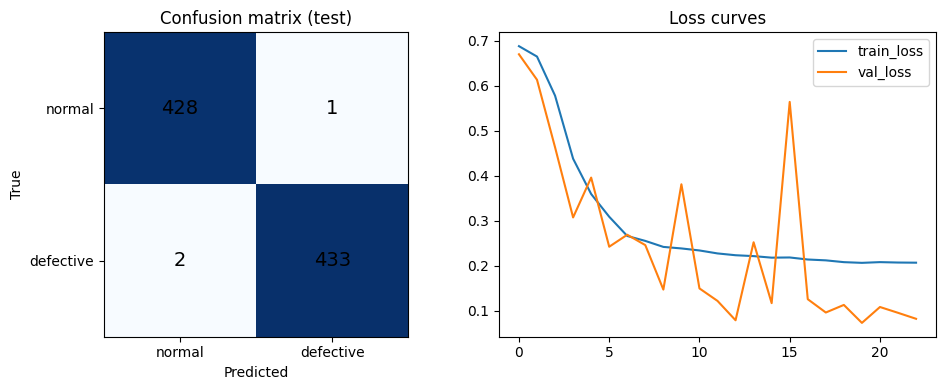

error
ok    861
FN      2
FP      1
Name: count, dtype: int64


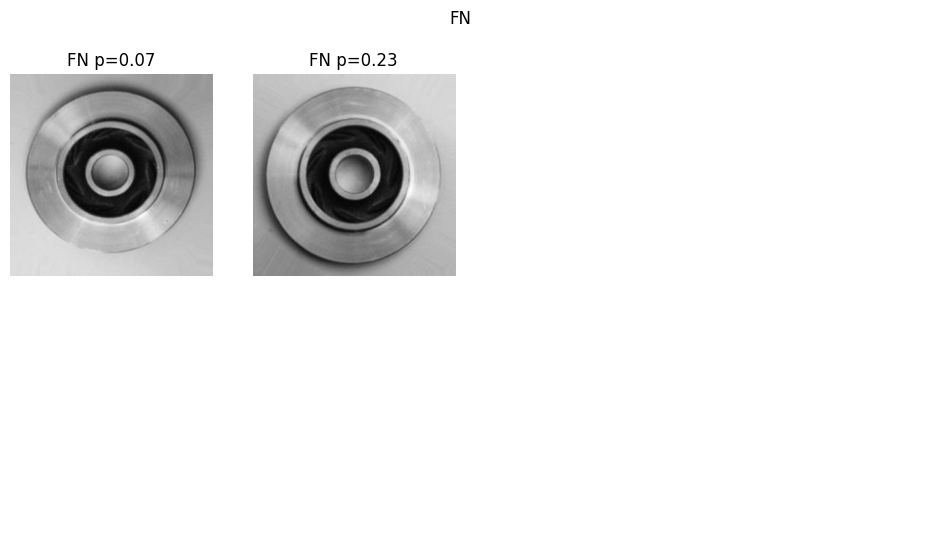

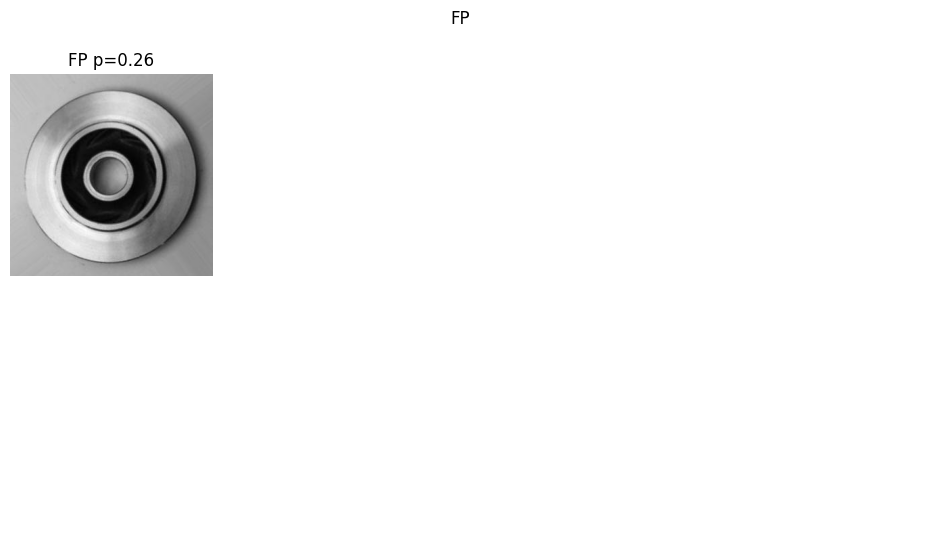

Params 0.027M | CPU 35.6 ms | GPU 2.7 ms


In [21]:
bp = study.best_params
MODEL_KEYS = ["width", "depth", "dropout", "pool", "spatial_drop"]

seed_everything()
tl, vl, te = make_loaders(bp["bs"], bp["rot"], bp["trans"])
model = LightCNN(**{k: bp[k] for k in MODEL_KEYS})
model, hist, _ = train_model(model, tl, vl, epochs=40, lr=bp["lr"], wd=bp["wd"], ls=bp["ls"], patience=10)

# Threshold chosen on VALIDATION (maximize F2: missing a defect is costlier than a false alarm)
pv, yv = predict(model, vl)
P, R, TH = precision_recall_curve(yv, pv)
f2 = 5 * P * R / (4 * P + R + 1e-9)
THR = float(TH[np.argmax(f2[:-1])])
print("Chosen threshold:", round(THR, 3))

# One-time TEST evaluation
pt, yt = predict(model, te)
pred = (pt >= THR).astype(int)
print(classification_report(yt, pred, target_names=["normal", "defective"], digits=4))
print("ROC-AUC", round(roc_auc_score(yt, pt), 4), "| AP", round(average_precision_score(yt, pt), 4))
cm = confusion_matrix(yt, pred); print(cm)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cm, cmap="Blues"); ax[0].set_title("Confusion matrix (test)")
for (i, j), v in np.ndenumerate(cm): ax[0].text(j, i, v, ha="center", va="center", fontsize=14)
ax[0].set_xticks([0, 1], ["normal", "defective"]); ax[0].set_yticks([0, 1], ["normal", "defective"])
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
hist[["train_loss", "val_loss"]].plot(ax=ax[1], title="Loss curves"); plt.tight_layout(); plt.show()

# Error analysis: FN = missed defects, FP = false alarms
test_df = df.iloc[idx["test"]].copy()            # same order as the test loader
test_df["prob"], test_df["pred"] = pt, pred
test_df["error"] = np.where((test_df.label == 1) & (test_df.pred == 0), "FN",
                    np.where((test_df.label == 0) & (test_df.pred == 1), "FP", "ok"))
print(test_df.error.value_counts())
test_df[test_df.error != "ok"].to_csv("errors.csv", index=False)

for kind in ["FN", "FP"]:
    e = test_df[test_df.error == kind].head(8)
    if len(e):
        fig, axes = plt.subplots(2, 4, figsize=(12, 6))
        for a in axes.ravel(): a.axis("off")
        for a, (_, r) in zip(axes.ravel(), e.iterrows()):
            a.imshow(Image.open(r.path), cmap="gray"); a.set_title(f"{kind} p={r.prob:.2f}")
        plt.suptitle(kind); plt.show()

# Latency (batch=1) and model size
def bench(m, dev, n=200):
    m = m.to(dev).eval(); x = torch.randn(1, 1, 300, 300, device=dev)
    with torch.no_grad():
        for _ in range(20): m(x)
        if dev == "cuda": torch.cuda.synchronize()
        t = time.perf_counter()
        for _ in range(n): m(x)
        if dev == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t) / n * 1000

cpu_ms = bench(model, "cpu")
gpu_ms = bench(model, "cuda") if device == "cuda" else float("nan")
print(f"Params {n_params(model):.3f}M | CPU {cpu_ms:.1f} ms | GPU {gpu_ms:.1f} ms")

model = model.to(device)
torch.save({"state_dict": model.state_dict(), "cfg": {k: bp[k] for k in MODEL_KEYS},
            "threshold": THR, "norm": "per_image"}, "model.pt")

**full Evaluation**

                thr=0.5  thr=0.248 (val-tuned)
threshold        0.5000                 0.2480
accuracy         0.9954                 0.9965
balanced_acc     0.9954                 0.9965
precision        1.0000                 0.9977
recall           0.9908                 0.9954
specificity      1.0000                 0.9977
f1               0.9954                 0.9965
f2               0.9926                 0.9959
mcc              0.9908                 0.9931
FPR              0.0000                 0.0023
FNR              0.0092                 0.0046
TP             431.0000               433.0000
FP               0.0000                 1.0000
TN             429.0000               428.0000
FN               4.0000                 2.0000
roc_auc          0.9989                 0.9989
avg_precision    0.9993                 0.9993
              precision    recall  f1-score   support

      normal     0.9953    0.9977    0.9965       429
   defective     0.9977    0.9954    0.9965  

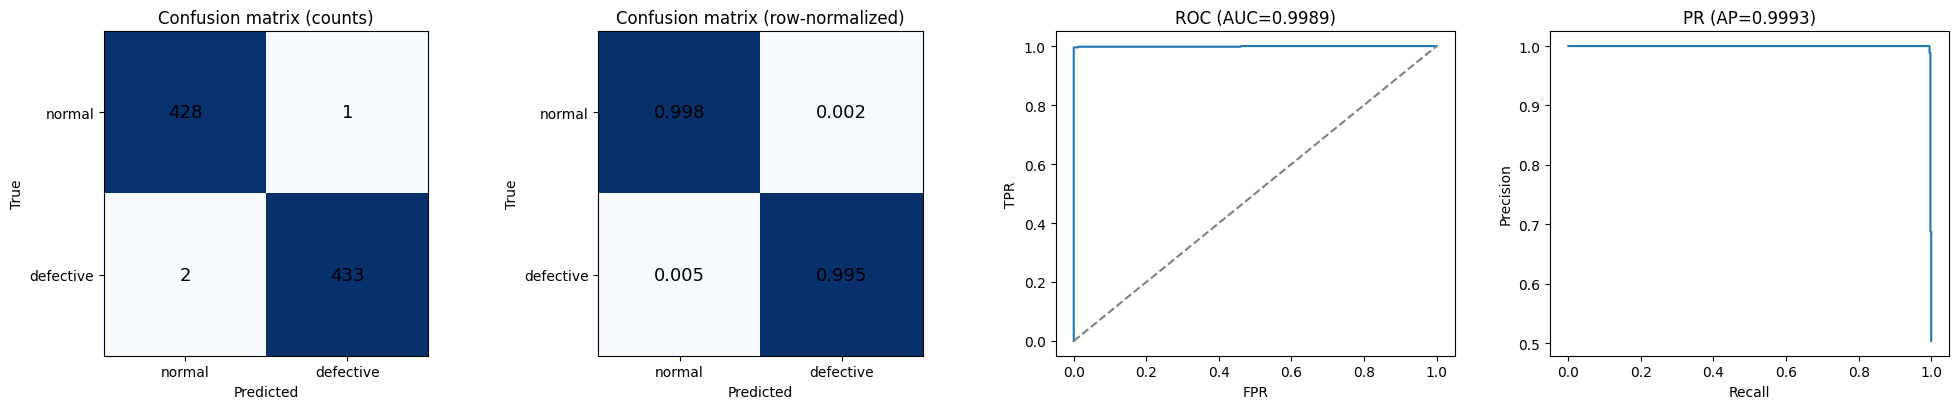

precision  95% CI: [0.9929, 1.0000]
recall     95% CI: [0.9882, 1.0000]
f1         95% CI: [0.9919, 1.0000]
roc_auc    95% CI: [0.9967, 1.0000]
 threshold  precision  recall     f1  FP  FN
      0.05     0.6214  1.0000 0.7665 265   0
      0.10     0.7736  0.9977 0.8715 127   1
      0.20     0.9666  0.9977 0.9819  15   1
      0.30     1.0000  0.9954 0.9977   0   2
      0.40     1.0000  0.9908 0.9954   0   4
      0.50     1.0000  0.9908 0.9954   0   4
      0.60     1.0000  0.9770 0.9884   0  10
      0.70     1.0000  0.9540 0.9765   0  20
      0.80     1.0000  0.9287 0.9631   0  31
      0.90     1.0000  0.7931 0.8846   0  90

Expected precision at lower defect prevalence (same recall/FPR):
  prevalence   50%: precision = 0.998
  prevalence   20%: precision = 0.991
  prevalence    5%: precision = 0.957
  prevalence    1%: precision = 0.812


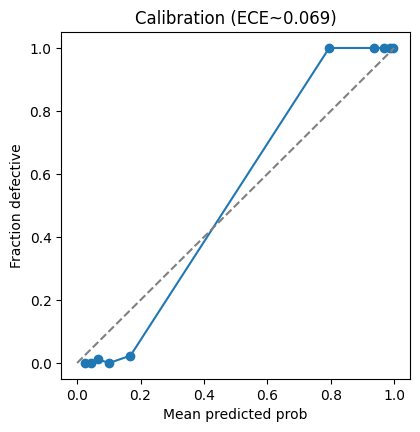

In [22]:
import json
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, matthews_corrcoef,
                             roc_curve, fbeta_score)
from sklearn.calibration import calibration_curve

def full_metrics(y, p, thr):
    pr = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pr, labels=[0, 1]).ravel()
    return dict(threshold=round(float(thr), 3), accuracy=accuracy_score(y, pr),
                balanced_acc=balanced_accuracy_score(y, pr),
                precision=precision_score(y, pr, zero_division=0), recall=recall_score(y, pr),
                specificity=tn / (tn + fp), f1=f1_score(y, pr), f2=fbeta_score(y, pr, beta=2),
                mcc=matthews_corrcoef(y, pr), FPR=fp / (fp + tn), FNR=fn / (fn + tp),
                TP=tp, FP=fp, TN=tn, FN=fn,
                roc_auc=roc_auc_score(y, p), avg_precision=average_precision_score(y, p))

# 1) Summary at default 0.5 vs the validation-chosen threshold
summary = pd.DataFrame({"thr=0.5": full_metrics(yt, pt, 0.5),
                        f"thr={THR:.3f} (val-tuned)": full_metrics(yt, pt, THR)}).T
print(summary.round(4).T)

# 2) Per-class report (precision / recall / F1 for both classes)
print(classification_report(yt, (pt >= THR).astype(int), target_names=["normal", "defective"], digits=4))

# 3) Plots: confusion matrix (counts + row-normalized), ROC, PR
cm = confusion_matrix(yt, (pt >= THR).astype(int))
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(1, 4, figsize=(20, 4.2))
for a, M, t, fmt in [(ax[0], cm, "Confusion matrix (counts)", "{:d}"), (ax[1], cmn, "Confusion matrix (row-normalized)", "{:.3f}")]:
    a.imshow(M, cmap="Blues"); a.set_title(t)
    for (i, j), v in np.ndenumerate(M): a.text(j, i, fmt.format(v), ha="center", va="center", fontsize=13)
    a.set_xticks([0, 1], ["normal", "defective"]); a.set_yticks([0, 1], ["normal", "defective"])
    a.set_xlabel("Predicted"); a.set_ylabel("True")
fpr, tpr, _ = roc_curve(yt, pt)
ax[2].plot(fpr, tpr); ax[2].plot([0, 1], [0, 1], "--", c="gray")
ax[2].set_title(f"ROC (AUC={roc_auc_score(yt, pt):.4f})"); ax[2].set_xlabel("FPR"); ax[2].set_ylabel("TPR")
Pc, Rc, _ = precision_recall_curve(yt, pt)
ax[3].plot(Rc, Pc); ax[3].set_title(f"PR (AP={average_precision_score(yt, pt):.4f})")
ax[3].set_xlabel("Recall"); ax[3].set_ylabel("Precision")
plt.tight_layout(); plt.savefig("eval_curves.png", dpi=150); plt.show()

# 4) Bootstrap 95% confidence intervals (test set is small, so report uncertainty)
rng = np.random.RandomState(SEED); n = len(yt); boots = []
for _ in range(1000):
    i = rng.randint(0, n, n)
    if len(np.unique(yt[i])) < 2: continue
    pr = (pt[i] >= THR).astype(int)
    boots.append([precision_score(yt[i], pr, zero_division=0), recall_score(yt[i], pr),
                  f1_score(yt[i], pr), roc_auc_score(yt[i], pt[i])])
ci = np.percentile(boots, [2.5, 97.5], axis=0)
for k, name in enumerate(["precision", "recall", "f1", "roc_auc"]):
    print(f"{name:10s} 95% CI: [{ci[0, k]:.4f}, {ci[1, k]:.4f}]")

# 5) Threshold sweep: the precision/recall trade-off for the client
rows = []
for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    m_ = full_metrics(yt, pt, t); rows.append({k: m_[k] for k in ["threshold", "precision", "recall", "f1", "FP", "FN"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))

# 6) Realistic prevalence: precision when defects are rare (the test set is 50/50)
m_ = full_metrics(yt, pt, THR); tpr_, fpr_ = m_["recall"], m_["FPR"]
print("\nExpected precision at lower defect prevalence (same recall/FPR):")
for prev in [0.5, 0.2, 0.05, 0.01]:
    prec = tpr_ * prev / (tpr_ * prev + fpr_ * (1 - prev) + 1e-12)
    print(f"  prevalence {prev:>5.0%}: precision = {prec:.3f}")

# 7) Calibration (is the confidence score trustworthy?)
frac_pos, mean_pred = calibration_curve(yt, pt, n_bins=10, strategy="quantile")
ece = np.mean(np.abs(frac_pos - mean_pred))
plt.figure(figsize=(4.5, 4.5)); plt.plot(mean_pred, frac_pos, "o-"); plt.plot([0, 1], [0, 1], "--", c="gray")
plt.xlabel("Mean predicted prob"); plt.ylabel("Fraction defective"); plt.title(f"Calibration (ECE~{ece:.3f})")
plt.savefig("calibration.png", dpi=150); plt.show()

# 8) Save everything for the README
json.dump({k: (float(v) if not isinstance(v, (int, str)) else v) for k, v in full_metrics(yt, pt, THR).items()},
          open("test_metrics.json", "w"), indent=2)
summary.to_csv("test_metrics_summary.csv")

In [23]:
import json, hashlib
from google.colab import files

# 1) Pure state_dict (weights only) + metadata the API needs
model = model.to("cpu").eval()
torch.save(model.state_dict(), "casting_lightcnn.pth")

meta = {
    "model_class": "LightCNN",
    "model_args": {k: bp[k] for k in MODEL_KEYS},     # width, depth, dropout, pool, spatial_drop
    "input": {"size": [300, 300], "channels": 1, "color": "grayscale",
              "scale": "x/255", "normalization": "per_image"},   # (x - mean(x)) / (std(x) + 1e-6), per image
    "threshold": THR,
    "classes": {"0": "normal", "1": "defective"},
    "output": "single logit; probability = sigmoid(logit); defective if prob >= threshold",
    "test_metrics": json.load(open("test_metrics.json")) if os.path.exists("test_metrics.json") else None,
}
json.dump(meta, open("model_config.json", "w"), indent=2)

# 2) Verify: rebuild from the saved files and compare outputs on real test images
ck = torch.load("casting_lightcnn.pth", map_location="cpu")
m2 = LightCNN(**meta["model_args"]); m2.load_state_dict(ck); m2.eval()

sample = X[idx["test"][:16]].float().div(255).unsqueeze(1)
sample = (sample - sample.mean((1, 2, 3), keepdim=True)) / (sample.std((1, 2, 3), keepdim=True) + 1e-6)
with torch.no_grad():
    diff = (model(sample) - m2(sample)).abs().max().item()
print("Max output difference after reload:", diff)            # should be ~0
print("Size:", round(os.path.getsize("casting_lightcnn.pth") / 1024, 1), "KB |",
      "sha256:", hashlib.sha256(open("casting_lightcnn.pth", "rb").read()).hexdigest()[:12])

# 3) Download (also grabs the model class so the API repo is self-contained)
files.download("casting_lightcnn.pth")
files.download("model_config.json")

Max output difference after reload: 0.0
Size: 124.9 KB | sha256: f8ed01f69863


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**ablations for the README**

In [24]:
def run(cfg, norm="per_image", epochs=20):
    """Train a fresh model under a given setting; evaluate on test at threshold 0.5."""
    seed_everything()
    tl_, vl_, te_ = make_loaders(bp["bs"], bp["rot"], bp["trans"], norm)
    m, _, _ = train_model(LightCNN(**cfg), tl_, vl_, epochs=epochs, lr=bp["lr"],
                          wd=bp["wd"], ls=bp["ls"], verbose=False)
    p, y = predict(m, te_); pr = p >= 0.5
    return dict(F1=f1_score(y, pr), Precision=precision_score(y, pr), Recall=recall_score(y, pr),
                AUC=roc_auc_score(y, p), params_M=n_params(m), cpu_ms=bench(m, "cpu"))

best_cfg = {k: bp[k] for k in MODEL_KEYS}
small_cfg = {**best_cfg, "width": 0.5, "depth": 3}          # even smaller model for the trade-off table

results = {
    "Best LightCNN, per-image norm":                     run(best_cfg),
    "Best LightCNN, global norm (brightness shortcut)":  run(best_cfg, norm="global"),
    "Smaller LightCNN (width 0.5, depth 3)":             run(small_cfg),
}
res_df = pd.DataFrame(results).T.round(4)
print(res_df)
res_df.to_csv("ablation_results.csv")

                                                      F1  Precision  Recall  \
Best LightCNN, per-image norm                     0.9954     1.0000  0.9908   
Best LightCNN, global norm (brightness shortcut)  0.9919     1.0000  0.9839   
Smaller LightCNN (width 0.5, depth 3)             0.9931     0.9977  0.9885   

                                                     AUC  params_M   cpu_ms  
Best LightCNN, per-image norm                     0.9981    0.0268  28.9185  
Best LightCNN, global norm (brightness shortcut)  0.9997    0.0268  22.7153  
Smaller LightCNN (width 0.5, depth 3)             0.9986    0.0076  11.9946  
